# Labelled image data

Generates spectrograms for a selection of images and labels the graphs correctly.

In [2]:
import os
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
import noisereduce as nr

/home/arian/Documents/Master/03-IMAA-IMS/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATA_DIR = "./data"
wav_file_paths = sorted(os.listdir(DATA_DIR))

In [7]:
def get_signal(path: str) -> np.ndarray:
    signal, sample_rate = sf.read(f"{DATA_DIR}/{path}")
    return signal, sample_rate

In [5]:
def get_denoised_signal(path: str, amp: int = 5):
    noise_reference_signal, sample_rate = get_signal(path)
    noise_lim = int(len(noise_reference_signal)/10)
    noise_sample = noise_reference_signal[:noise_lim]

    audio_data, _ = get_signal(path)

    reduced_noise_audio = nr.reduce_noise(y=audio_data, sr=sample_rate, y_noise=noise_sample, prop_decrease=0.999, stationary=True, n_std_thresh_stationary=4.0)

    compressed_audio = np.tanh(reduced_noise_audio * 1.5)
    max_peak = np.max(np.abs(compressed_audio))
    if max_peak > 0:
        reduced_noise_audio = (compressed_audio / max_peak) * 1.0

    return reduced_noise_audio * amp, sample_rate

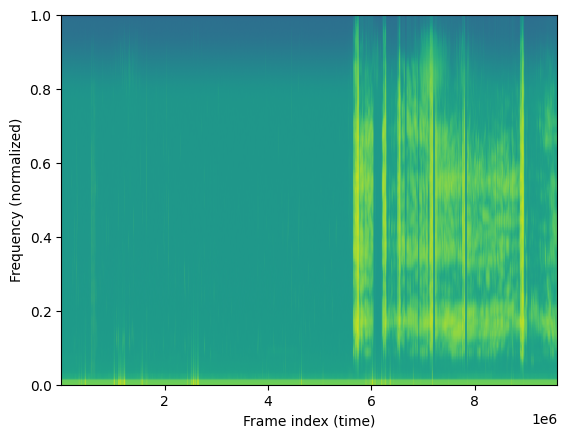

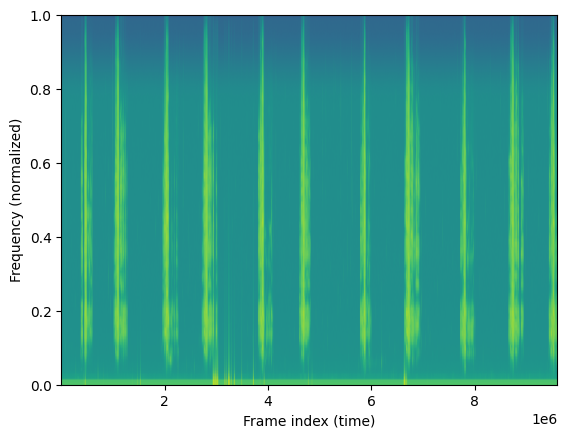

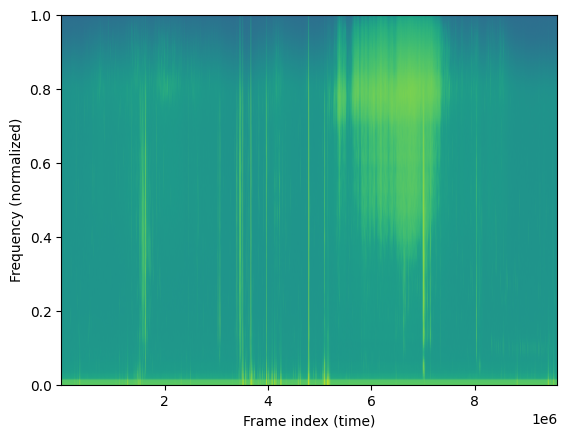

In [9]:
TARGET_INDICES = [1,3,6]
for index in TARGET_INDICES:
    signal, _ = get_denoised_signal(wav_file_paths[index])
    plt.specgram(signal)
    plt.ylabel("Frequency (normalized)")
    plt.xlabel("Frame index (time)")
    plt.show()